In [1]:
#Libraries for Machine Learning
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
fall = pd.read_csv('Dataset/fall.csv', header = None)
non_fall = pd.read_csv('Dataset/nf.csv', header = None)
rest = pd.read_csv('Dataset/rest.csv', header = None)

fall[0] = 1
non_fall[0] = 2
rest[0] = 3

fin = pd.concat([fall,non_fall,rest])
fin = fin.sample(frac = 1)

In [3]:
x_inp = fin.iloc[:,1:].values
y_inp = fin.iloc[:,0].values

In [4]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_inp, y_inp, random_state = 0)

In [5]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [6]:
from matplotlib.colors import ListedColormap

def LDA_Plot(x_val, y_val, x_test, y_test, func, step = 0.01, title = "Title", dpi = 800):
    plt.figure(dpi = dpi)
    
    x_set, y_set = x_val, y_val
    #To get a meshgrid for plotting on contour
    x1, x2 = np.meshgrid( np.arange(start = x_set[:,0].min() - 1, stop = x_set[:,0].max() + 1, step = step),
                          np.arange(start = x_set[:,1].min() - 1, stop = x_set[:,1].max() + 1, step = step))
    #Plotting on the contour
    Z = func(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape)
    plt.contourf(x1, x2, Z,
                 cmap = ListedColormap(('red', 'green', 'blue')), alpha = 0.75)
    #Limiting the plot to max & min units of x1 & x2
    plt.xlim(x1.min(), x1.max())
    plt.ylim(x2.min(), x2.max())
    plt.title("Decision Boundary - " + title)
    plt.savefig("Snips\\Decision Boundary - " + title)
    plt.show()
    
    plt.figure(dpi = dpi)
    
    plt.contourf(x1, x2, Z,
                 cmap = ListedColormap(('red', 'green', 'blue')), alpha = 0.75)
    #Limiting the plot to max & min units of x1 & x2
    plt.xlim(x1.min(), x1.max())
    plt.ylim(x2.min(), x2.max())
    #Scatter plot of y_val
    for i, j in enumerate(np.unique(y_test)):
        plt.scatter(x_test[y_test==j, 0], x_test[y_test==j, 1], 
                    color = ListedColormap(("#8B0000", 'green', '#0000A0'))(i), label= j, s = 0.5) #Dark Red & Blue for clear visibility
    plt.title( "Scatter Plot on Decision Boundary - " + title)
    plt.legend()
    plt.savefig("Snips\\Scatter Plot on Decision Boundary - " + title)
    plt.show()

## Logistic Regression

In [48]:
from sklearn.linear_model import LogisticRegression
classifier_Lreg = LogisticRegression(random_state=0)
classifier_Lreg.fit(x_train, y_train)
y_pred = classifier_Lreg.predict(x_train)

In [49]:
#Confusion Matrix & Accuracy for evaluating the model for training data

from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_train, y_pred)
print("Confusion Matrix (Train Data): \n", cm)

accuracy = accuracy_score(y_train, y_pred)
print("Accuracy (Train Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Train Data): 
 [[6271 1619 1900]
 [ 764 7152  105]
 [   0    0 8559]]
Accuracy (Train Data): 83.36 %


In [50]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Train Data: ", sen[0])
print("Sensitivity of Non-Fall for Train Data: ", sen[1])
print("Sensitivity of Rest for Train Data: ", sen[2])
print("Sensitivity of Train Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Train Data: ", spec[0] )
print("Specificity of Non-Fall for Train Data: ",  spec[1] )
print("Specificity of Rest for Train Data: ",  spec[2])
print("Specificity of Train Data: ", spec.mean()*100, "%")

Sensitivity of Fall for Train Data:  0.8914001421464108
Sensitivity of Non-Fall for Train Data:  0.8154144339299966
Sensitivity of Rest for Train Data:  0.8102044680045437
Sensitivity of Train Data:  83.90063480269838 %
Specificity of Fall for Train Data:  0.8125678820791311
Specificity of Non-Fall for Train Data:  0.8426615148587988
Specificity of Rest for Train Data:  0.8492344679235734
Specificity of Train Data:  83.48212882871677 %


In [51]:
# Confusion Matrix & Accuracy for evaluating the model for test data

y_pred = classifier_Lreg.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[2090  543  634]
 [ 267 2336   40]
 [   0    0 2881]]
Accuracy (Test Data): 83.12 %


In [52]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Test Data: ", sen[0])
print("Sensitivity of Non-Fall for Test Data: ", sen[1])
print("Sensitivity of Rest for Test Data: ", sen[2])
print("Sensitivity of Test Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Test Data: ", spec[0] )
print("Specificity of Non-Fall for Test Data: ",  spec[1] )
print("Specificity of Rest for Test Data: ",  spec[2])
print("Specificity of Test Data: ", spec.mean()*100, "%")

Sensitivity of Fall for Test Data:  0.886720407297412
Sensitivity of Non-Fall for Test Data:  0.8113928447377562
Sensitivity of Rest for Test Data:  0.810407876230661
Sensitivity of Test Data:  83.6173709421943 %
Specificity of Fall for Test Data:  0.8108486167236556
Specificity of Non-Fall for Test Data:  0.8408322056833559
Specificity of Rest for Test Data:  0.8453017570664629
Specificity of Test Data:  83.23275264911581 %


In [12]:
# 10 Fold CV accuracy

from sklearn.model_selection import cross_val_score

accuracies = cross_val_score(estimator=classifier_Lreg, X=x_inp, y=y_inp, cv=10, n_jobs=-1)
print("Mean of Accuracies: {:.2f} %".format(accuracies[1:].mean()*100))
print("Std of Accuracies: ", accuracies[1:].std())

Mean of Accuracies: 84.09 %
Std of Accuracies:  0.005839196672567361


In [53]:
# Checking the optimal value of k such that, good amount of variance is retained
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=None)
z_train = lda.fit_transform(x_train, y_train)
z_test = lda.transform(x_test)
explained_variance = lda.explained_variance_ratio_

# explained_variance gives us the non-cummulative value of the varaince retained
variance_retained = 0

# Finding the variance retained for decrease in principal components
for k, evr in enumerate(explained_variance):
    variance_retained += evr 
    print("No. of Principal Components: ", k, " Explained Variance Ratio: {:.4f}".format(evr), " Variance Retained: {:.2f} %".format(variance_retained*100))
    if (variance_retained >= 0.98):
        # Finding the smallest value of k such that 98% of the variance is reatined
        break

No. of Principal Components:  0  Explained Variance Ratio: 0.7974  Variance Retained: 79.74 %
No. of Principal Components:  1  Explained Variance Ratio: 0.2026  Variance Retained: 100.00 %


In [14]:
# Choosing k, such that 98% of the variance is reatined.
# But, here even for k = 1, 100% variance is retained. So, for better data visualisation k=2 is chosen
lda = LDA(n_components=2)
# Transforming z_train & z_test using the new reduced dimension vector (U_reduce)
z_train = lda.fit_transform(x_train, y_train)
z_test = lda.transform(x_test)

In [15]:
# Analysing the SVM model fit with z_train
classifier_z = LogisticRegression(random_state=0)
classifier_z.fit(z_train, y_train)
y_z_pred = classifier_z.predict(z_train)

In [16]:
cm = confusion_matrix(y_z_pred, y_train)
print("Confustion Matrix (Z-Test Data): \n", cm)
accuracy = accuracy_score(y_train, y_z_pred)
print("Accuracy (Z-Train Data): {:.2f} %".format(accuracy*100))

Confustion Matrix (Z-Test Data): 
 [[6213  767    0]
 [1664 7148    0]
 [1913  106 8559]]
Accuracy (Z-Train Data): 83.12 %


In [17]:
y_z_pred = classifier_z.predict(z_test)

cm = confusion_matrix(y_test, y_z_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_z_pred)
print("Accuracy (Z-Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[2071  564  632]
 [ 265 2338   40]
 [   0    0 2881]]
Accuracy (Z-Test Data): 82.93 %


In [18]:
# 10_Fold CV accuracy

z_inp = lda.transform(x_inp)

accuracies = cross_val_score(estimator=classifier_z, X=z_inp, y=y_inp, cv=10, n_jobs=-1)
print("Mean of Accuracies: {:.2f} %".format(accuracies[1:].mean()*100))
print("Std of Accuracies: ", accuracies[1:].std())

Mean of Accuracies: 83.46 %
Std of Accuracies:  0.00720889869533575


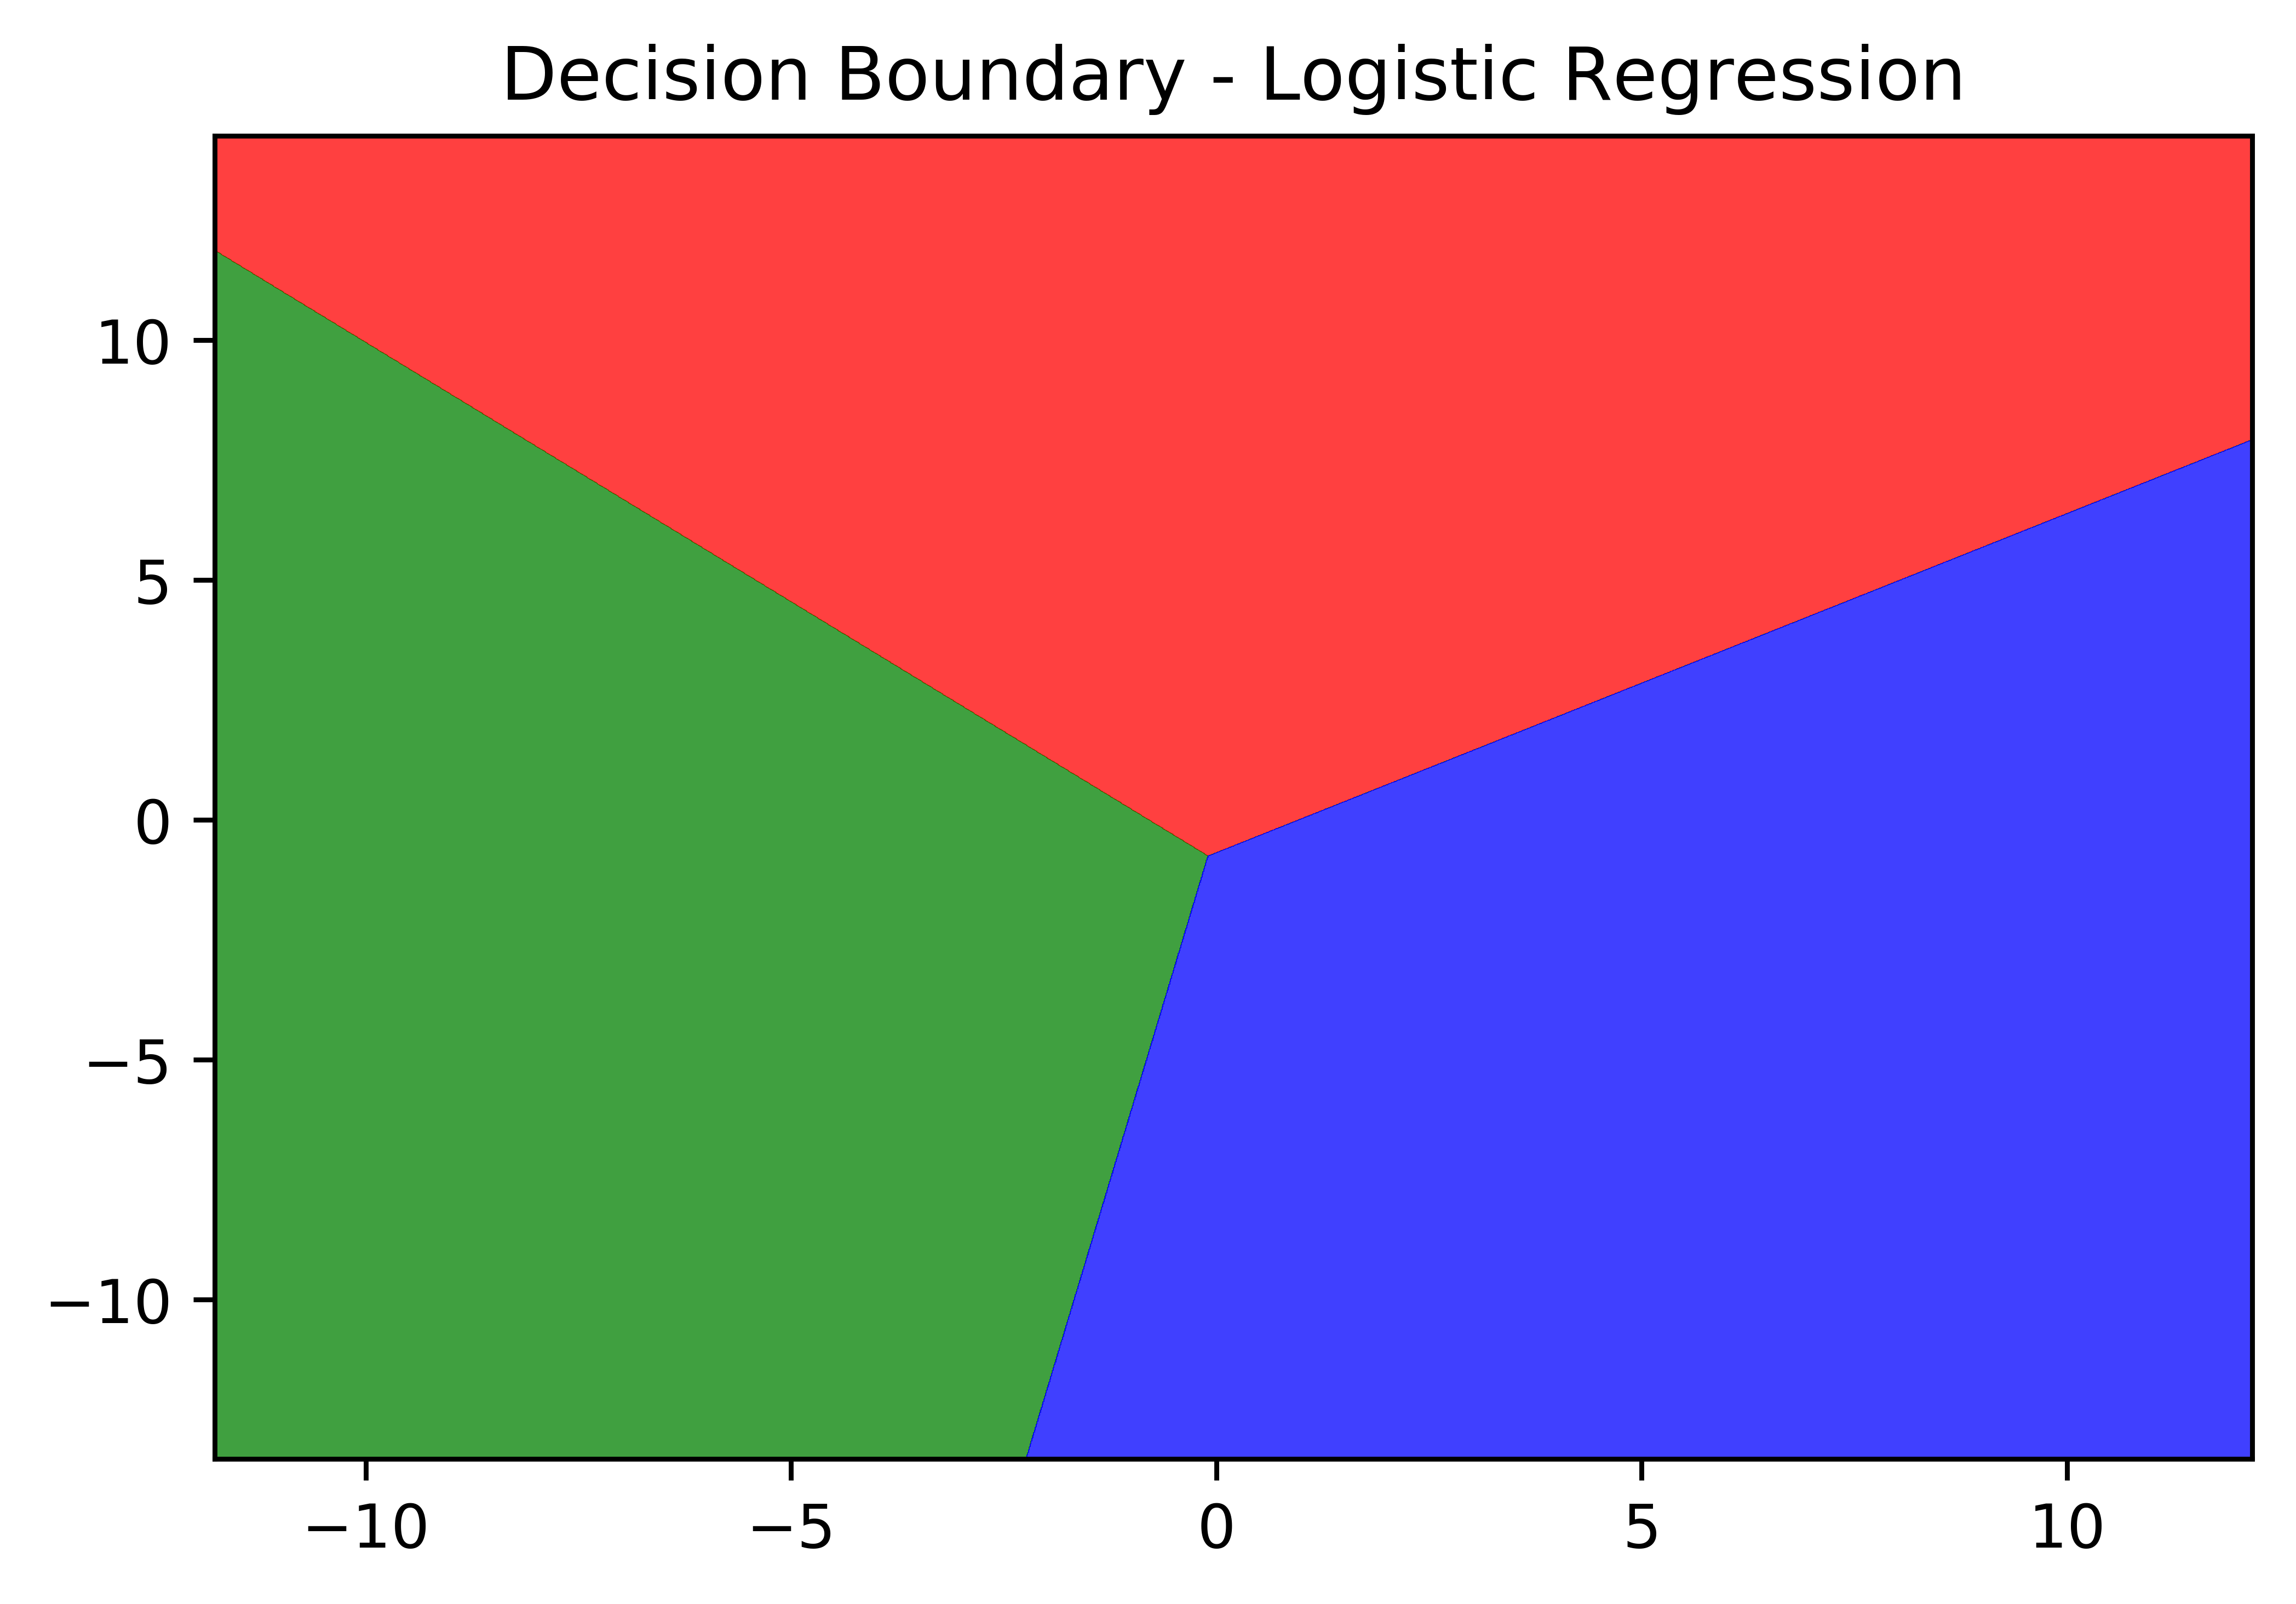

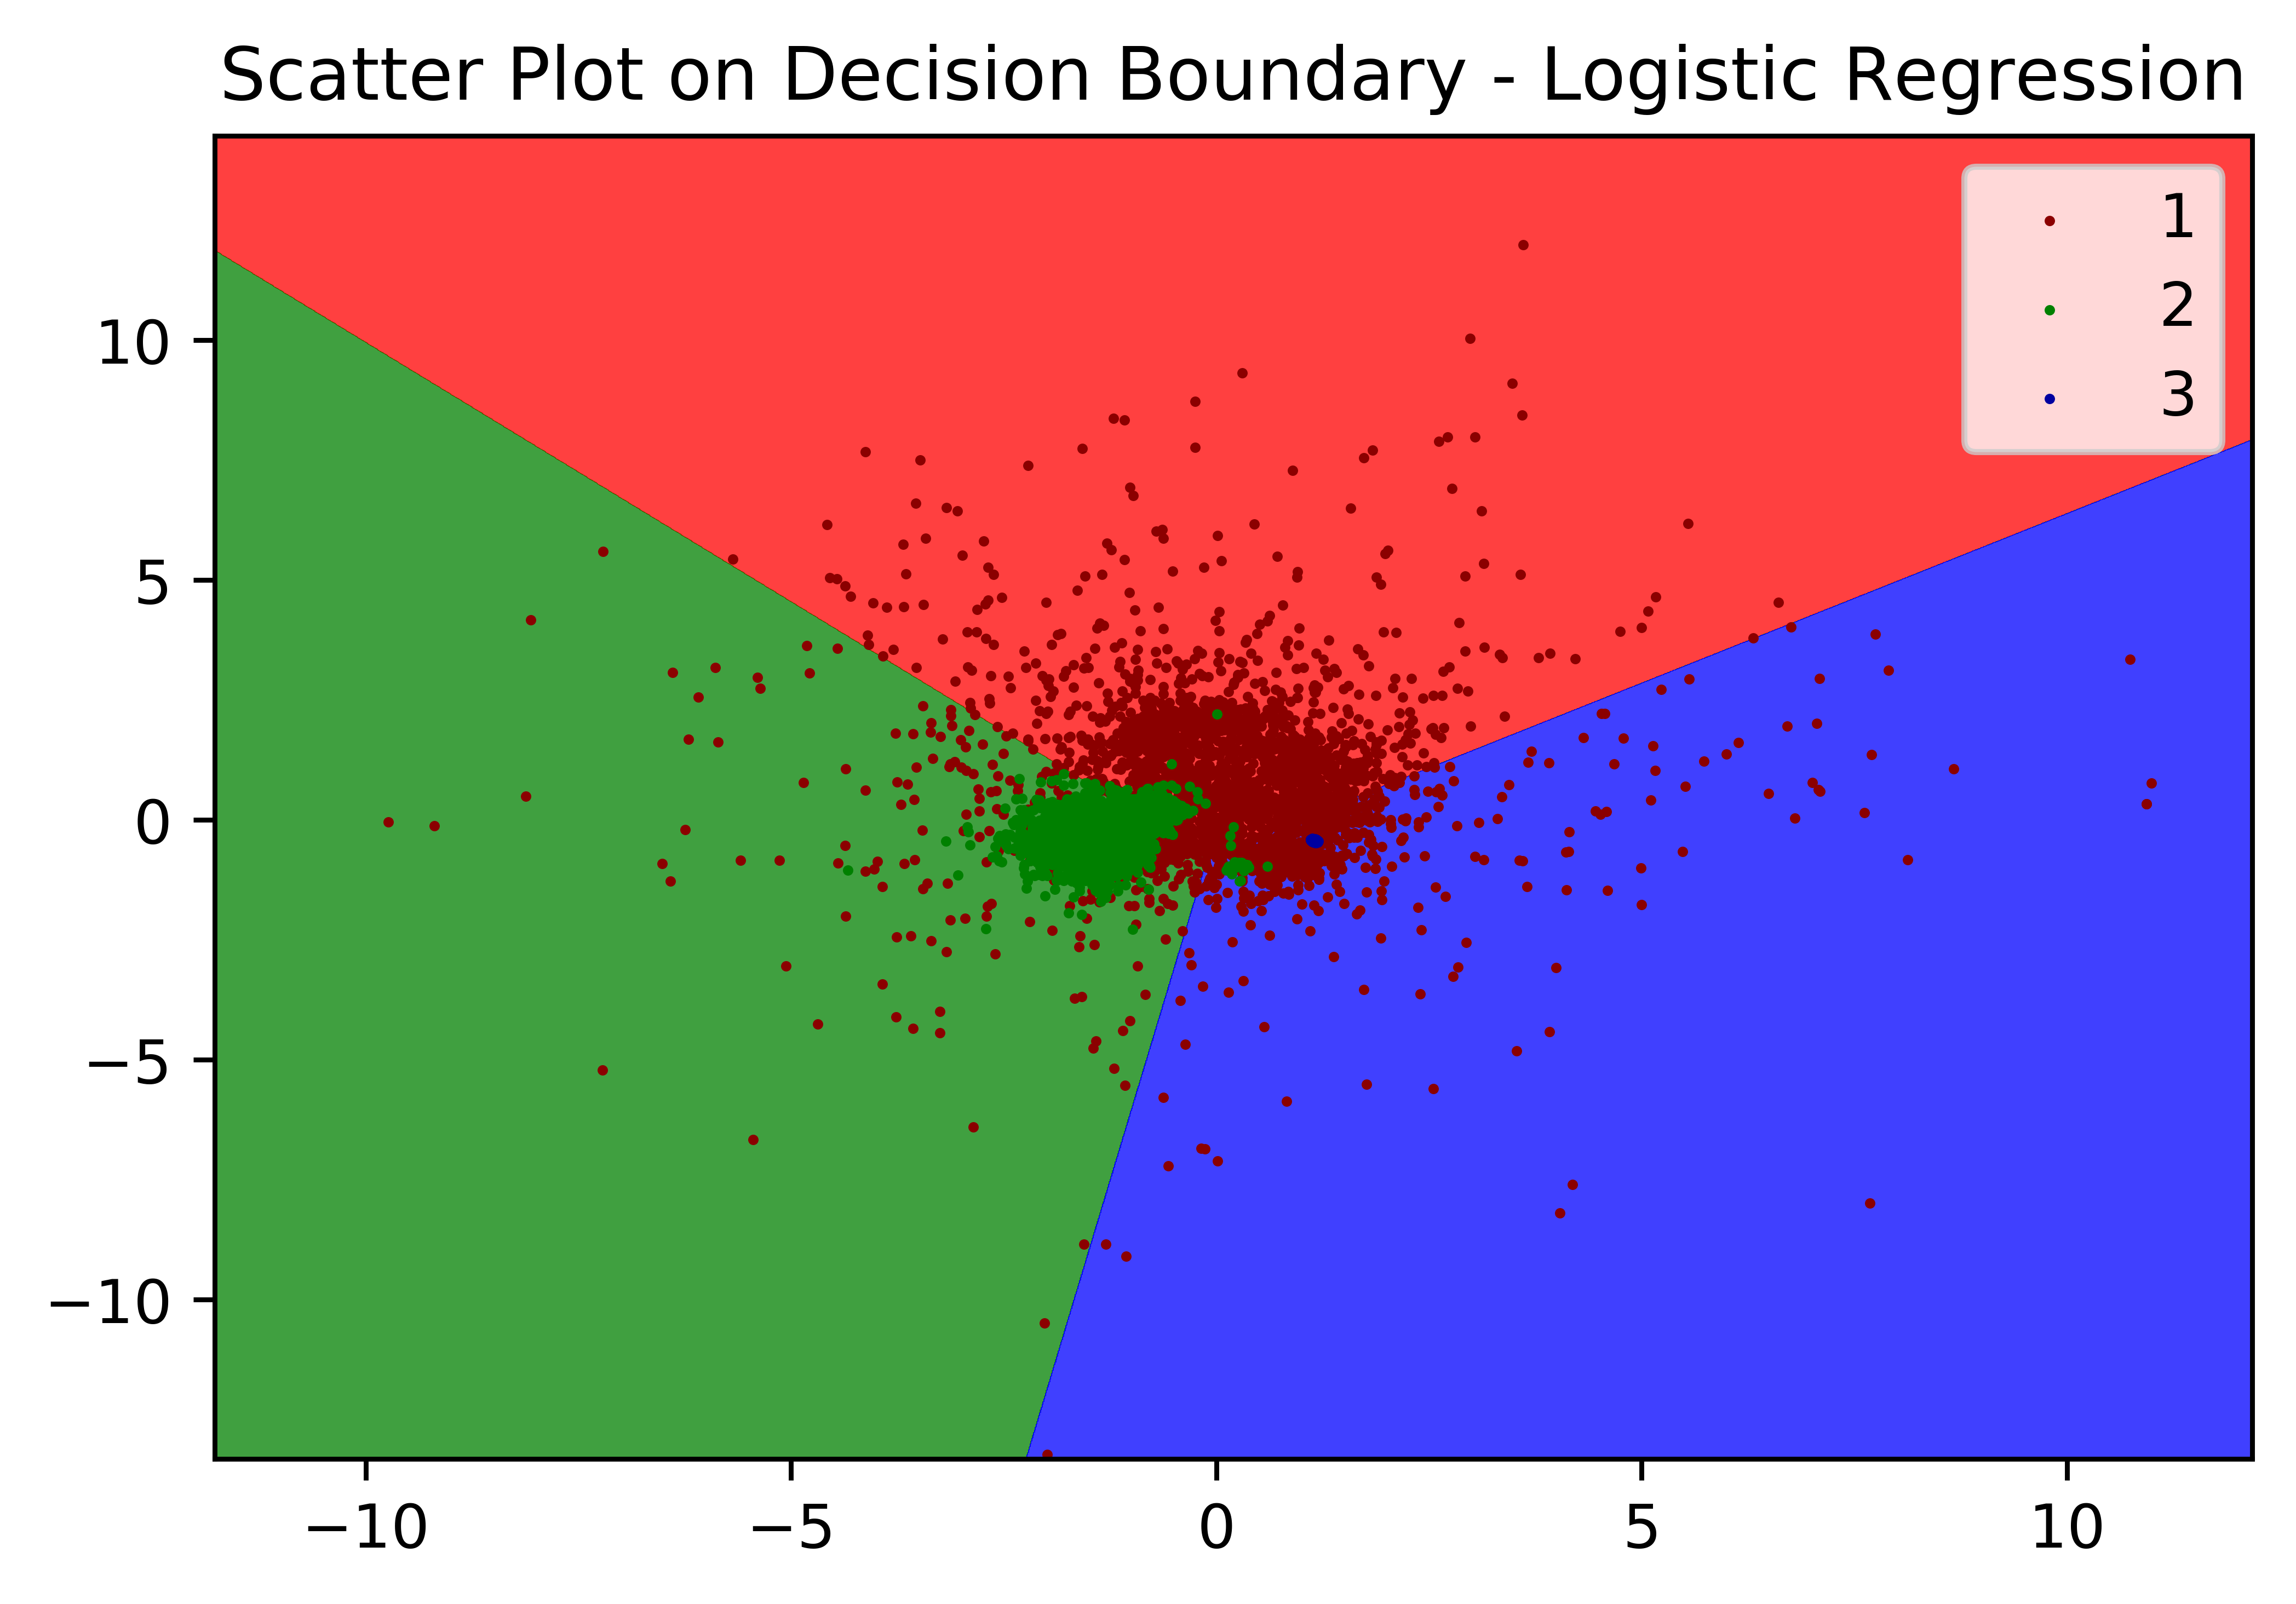

In [31]:
LDA_Plot(z_train, y_train, z_test, y_test, func = classifier_z.predict ,title = "Logistic Regression")

## k - Nearest Neighbours

In [43]:
from sklearn.neighbors import KNeighborsClassifier
classifier_kNN = KNeighborsClassifier(n_neighbors=10, metric='minkowski', p=2)
classifier_kNN.fit(x_train, y_train)

y_pred = classifier_kNN.predict(x_train)

In [44]:
#Confusion Matrix & Accuracy for evaluating the model for training data

from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(y_train, y_pred)
print("Confusion Matrix (Train Data): \n", cm)

accuracy = accuracy_score(y_train, y_pred)
print("Accuracy (Train Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Train Data): 
 [[9478  305    7]
 [ 155 7866    0]
 [   0    0 8559]]
Accuracy (Train Data): 98.23 %


In [45]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Train Data: ", sen[0])
print("Sensitivity of Non-Fall for Train Data: ", sen[1])
print("Sensitivity of Rest for Train Data: ", sen[2])
print("Sensitivity of Train Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Train Data: ", spec[0] )
print("Specificity of Non-Fall for Train Data: ",  spec[1] )
print("Specificity of Rest for Train Data: ",  spec[2])
print("Specificity of Train Data: ", spec.mean()*100, "%")

Sensitivity of Fall for Train Data:  0.9839094778366033
Sensitivity of Non-Fall for Train Data:  0.9626728674580834
Sensitivity of Rest for Train Data:  0.9991828157833295
Sensitivity of Train Data:  98.19217203593388 %
Specificity of Fall for Train Data:  0.9813586664276752
Specificity of Non-Fall for Train Data:  0.9910984120006594
Specificity of Rest for Train Data:  0.974163109413615
Specificity of Train Data:  98.22067292806497 %


In [46]:
# Confusion Matrix & Accuracy for evaluating the model for test data

y_pred = classifier_kNN.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[3145  115    7]
 [  52 2591    0]
 [   0    0 2881]]
Accuracy (Test Data): 98.02 %


In [47]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Test Data: ", sen[0])
print("Sensitivity of Non-Fall for Test Data: ", sen[1])
print("Sensitivity of Rest for Test Data: ", sen[2])
print("Sensitivity of Test Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Test Data: ", spec[0] )
print("Specificity of Non-Fall for Test Data: ",  spec[1] )
print("Specificity of Rest for Test Data: ",  spec[2])
print("Specificity of Test Data: ", spec.mean()*100, "%")

Sensitivity of Fall for Test Data:  0.9837347513293713
Sensitivity of Non-Fall for Test Data:  0.9575018477457502
Sensitivity of Rest for Test Data:  0.9975761772853186
Sensitivity of Test Data:  97.96042587868133 %
Specificity of Fall for Test Data:  0.978190918841616
Specificity of Non-Fall for Test Data:  0.990304026294166
Specificity of Rest for Test Data:  0.9717093003557513
Specificity of Test Data:  98.0068081830511 %


In [24]:
# 10_Fold CV accuracy

from sklearn.model_selection import cross_val_score

accuracies = cross_val_score(estimator=classifier_kNN, X=x_inp, y=y_inp, cv=10, n_jobs=-1)
print("Mean of Accuracies: {:.2f} %".format(accuracies[1:].mean()*100))
print("Std of Accuracies: ", accuracies[1:].std())

Mean of Accuracies: 97.57 %
Std of Accuracies:  0.0026345171281337834


In [55]:
# Checking the optimal value of k such that, good amount of variance is retained
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=None)
z_train = lda.fit_transform(x_train, y_train)
z_test = lda.transform(x_test)
explained_variance = lda.explained_variance_ratio_

# explained_variance gives us the non-cummulative value of the varaince retained
variance_retained = 0

# Finding the variance retained for decrease in principal components
for k, evr in enumerate(explained_variance):
    variance_retained += evr 
    print("No. of Principal Components: ", k, " Explained Variance Ratio: {:.4f}".format(evr), " Variance Retained: {:.2f} %".format(variance_retained*100))
    if (variance_retained >= 0.98):
        # Finding the smallest value of k such that 98% of the variance is reatined
        break

No. of Principal Components:  0  Explained Variance Ratio: 0.7974  Variance Retained: 79.74 %
No. of Principal Components:  1  Explained Variance Ratio: 0.2026  Variance Retained: 100.00 %


In [26]:
# Choosing k, such that 98% of the variance is reatined.
# But, here even for k = 1, 100% variance is retained. So, for better data visualisation k=2 is chosen
lda = LDA(n_components=2)
# Transforming z_train & z_test using the new reduced dimension vector (U_reduce)
z_train = lda.fit_transform(x_train, y_train)
z_test = lda.transform(x_test)

In [27]:
# Analysing the SVM model fit with z_train

classifier_z = KNeighborsClassifier(n_neighbors=10, metric='minkowski', p=2)
classifier_z.fit(z_train, y_train)
y_z_pred = classifier_z.predict(z_train)

In [28]:
cm = confusion_matrix(y_z_pred, y_train)
print("Confustion Matrix (Z-Test Data): \n", cm)
accuracy = accuracy_score(y_train, y_z_pred)
print("Accuracy (Z-Train Data): {:.2f} %".format(accuracy*100))

Confustion Matrix (Z-Test Data): 
 [[8925  634    0]
 [ 850 7387    0]
 [  15    0 8559]]
Accuracy (Z-Train Data): 94.32 %


In [29]:
y_z_pred = classifier_z.predict(z_test)

cm = confusion_matrix(y_test, y_z_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_z_pred)
print("Accuracy (Z-Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[2948  313    6]
 [ 237 2406    0]
 [   0    0 2881]]
Accuracy (Z-Test Data): 93.68 %


In [30]:
# 10_Fold CV accuracy

z_inp = lda.transform(x_inp)

accuracies = cross_val_score(estimator=classifier_z, X=z_inp, y=y_inp, cv=10, n_jobs=-1)
print("Mean of Accuracies: {:.2f} %".format(accuracies[1:].mean()*100))
print("Std of Accuracies: ", accuracies[1:].std())

Mean of Accuracies: 92.61 %
Std of Accuracies:  0.003596197281235317


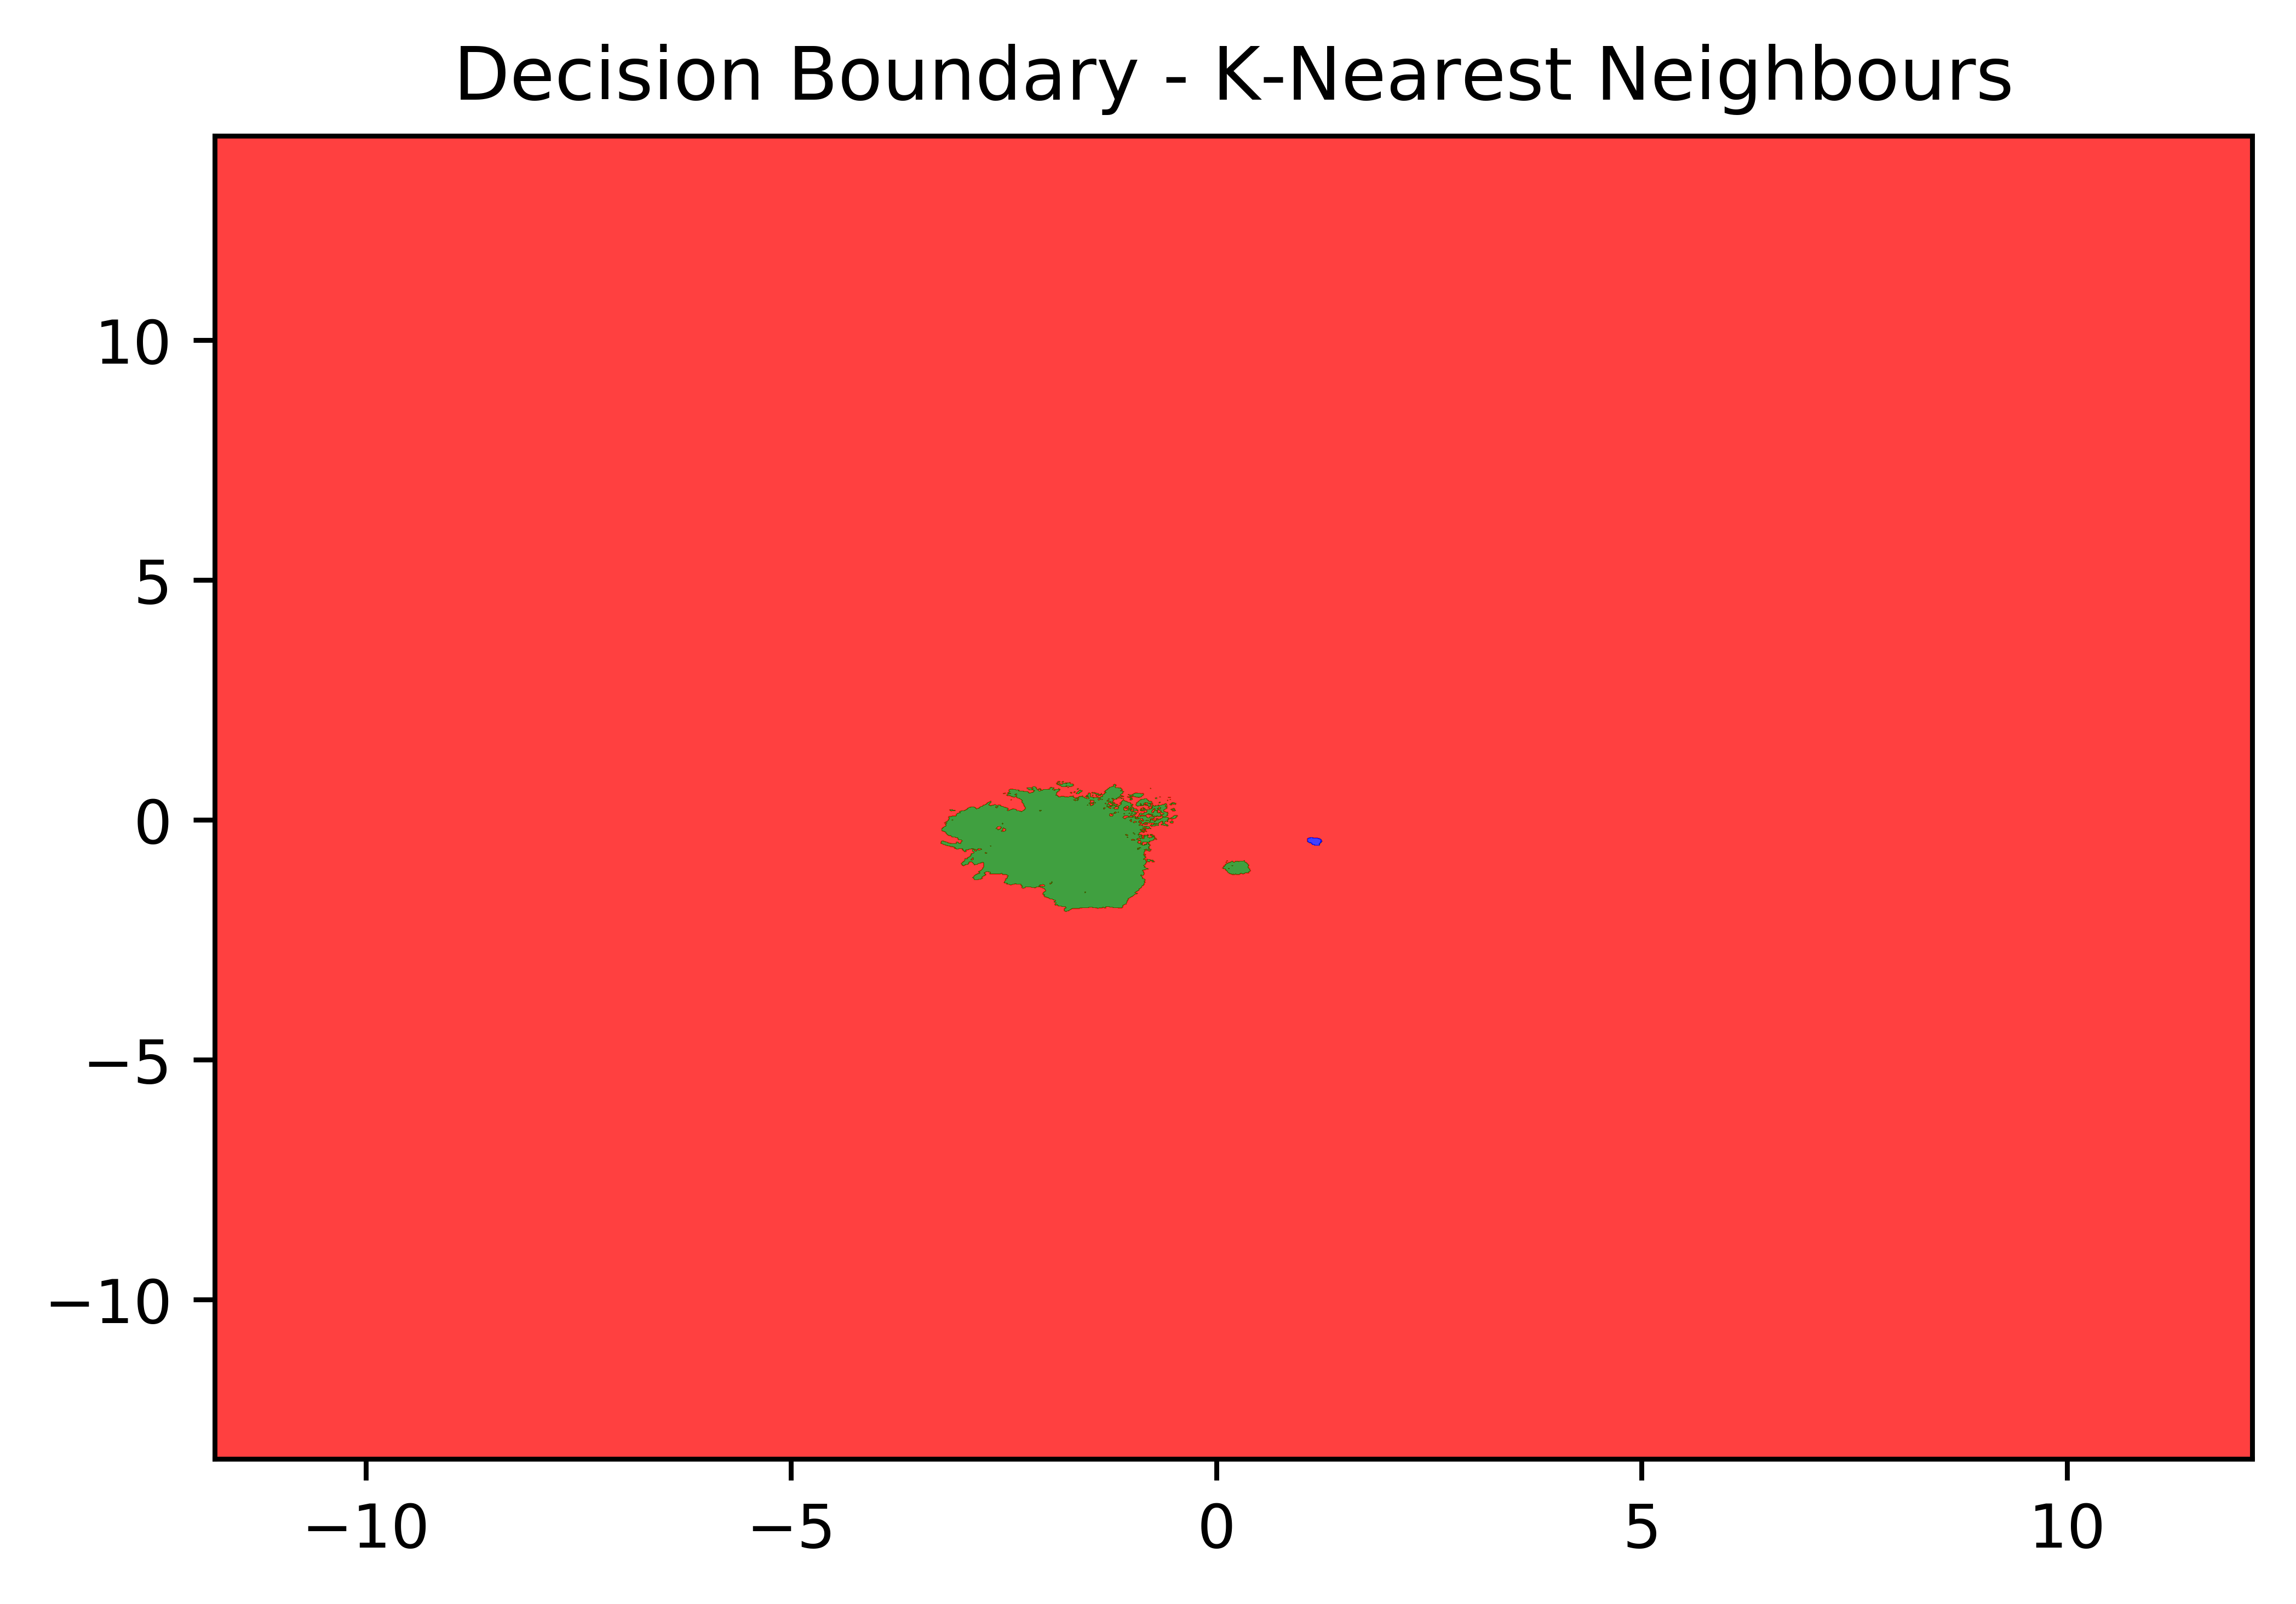

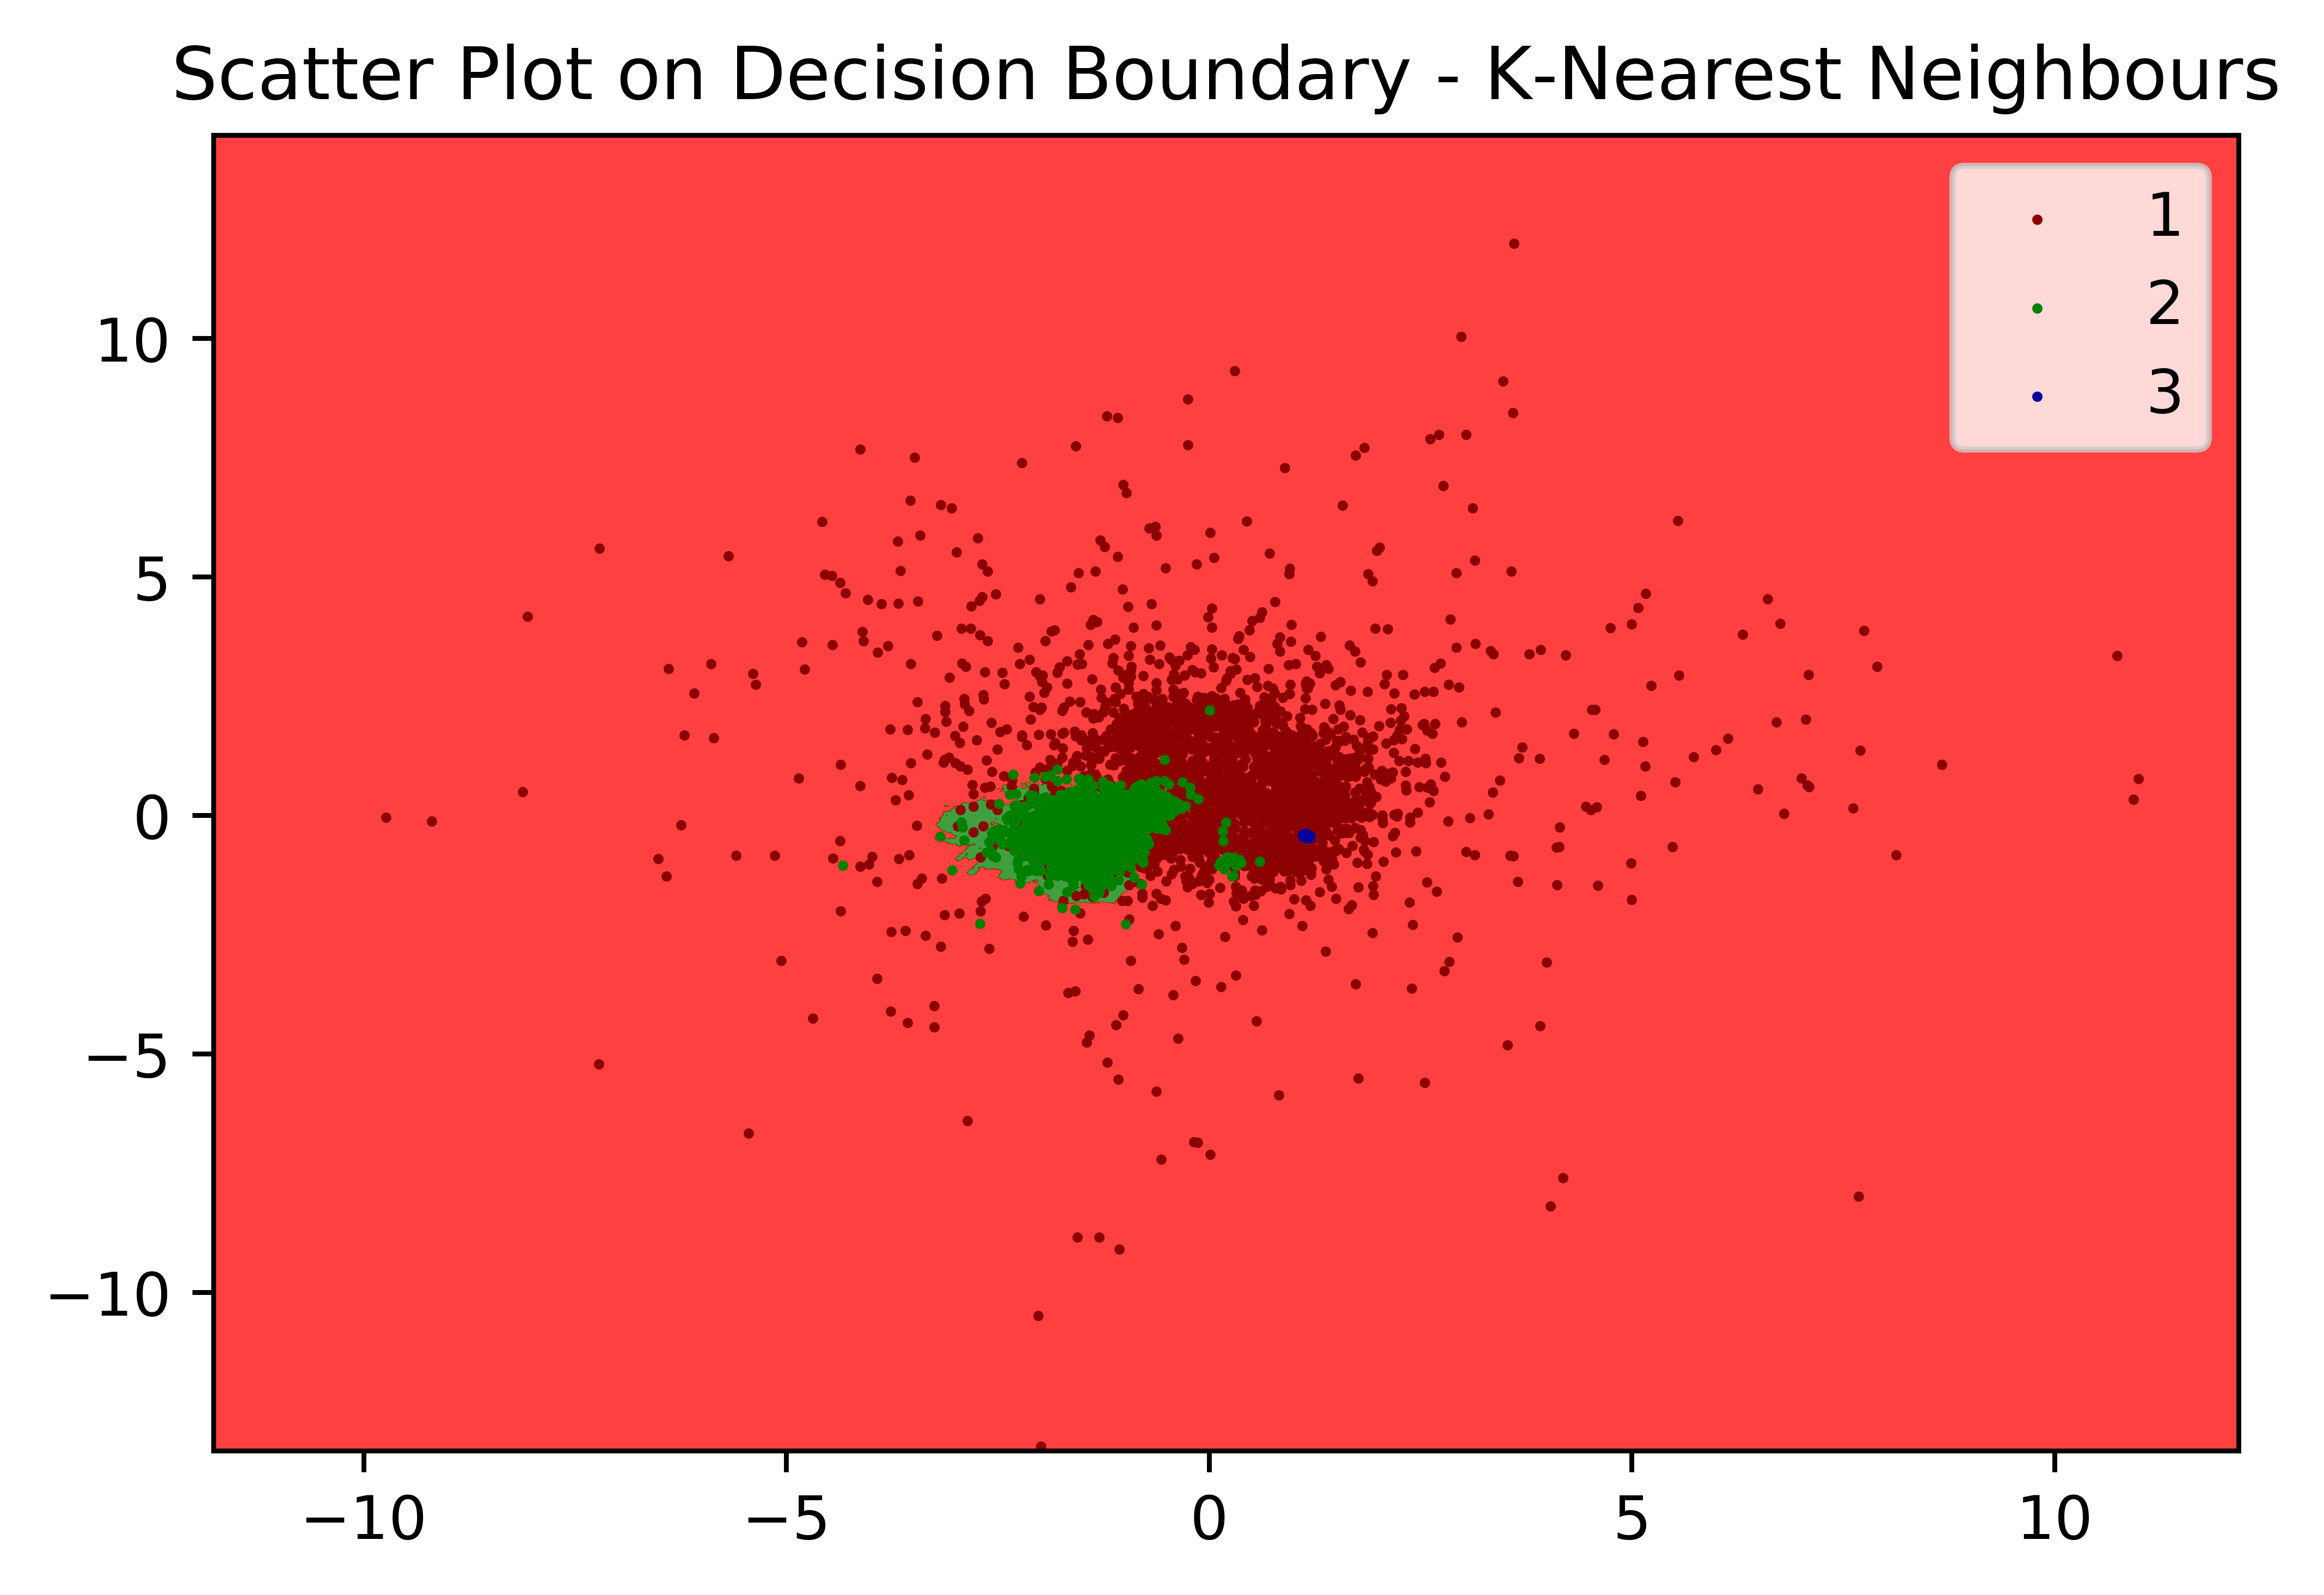

In [29]:
LDA_Plot(z_train, y_train, z_test, y_test, func = classifier_z.predict ,title = "K-Nearest Neighbours")

## Kernel SVM

In [31]:
from sklearn.svm import SVC
classifier_svm = SVC(kernel = 'rbf', random_state=0) # rbf (Radial Basis function) is same as gaussian kernel 
classifier_svm.fit(x_train, y_train)

y_pred = classifier_svm.predict(x_train)

In [32]:
#Confusion Matrix & Accuracy for evaluating the model for training data

from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_train, y_pred)
print("Confusion Matrix (Train Data): \n", cm)

accuracy = accuracy_score(y_train, y_pred)
print("Accuracy (Train Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Train Data): 
 [[9292  362  136]
 [ 365 7656    0]
 [   0    0 8559]]
Accuracy (Train Data): 96.73 %


In [33]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Train Data: ", sen[0])
print("Sensitivity of Non-Fall for Train Data: ", sen[1])
print("Sensitivity of Rest for Train Data: ", sen[2])
print("Sensitivity of Train Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Train Data: ", spec[0] )
print("Specificity of Non-Fall for Train Data: ",  spec[1] )
print("Specificity of Rest for Train Data: ",  spec[2])
print("Specificity of Train Data: ", spec.mean()*100, "%")

Sensitivity of Fall for Train Data:  0.962203582893238
Sensitivity of Non-Fall for Train Data:  0.9548515839361437
Sensitivity of Rest for Train Data:  0.9843588269120184
Sensitivity of Train Data:  96.71379979138001 %
Specificity of Fall for Train Data:  0.9702028361155987
Specificity of Non-Fall for Train Data:  0.9727005231037489
Specificity of Rest for Train Data:  0.9588684582743988
Specificity of Train Data 96.72572724979153 %


In [34]:
# Confusion Matrix & Accuracy for evaluating the model for test data

y_pred = classifier_svm.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[3105  119   43]
 [ 119 2524    0]
 [   0    0 2881]]
Accuracy (Test Data): 96.80 %


In [35]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Test Data: ", sen[0])
print("Sensitivity of Non-Fall for Test Data: ", sen[1])
print("Sensitivity of Rest for Test Data: ", sen[2])
print("Sensitivity of Test Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Test Data: ", spec[0] )
print("Specificity of Non-Fall for Test Data: ",  spec[1] )
print("Specificity of Rest for Test Data: ",  spec[2])
print("Specificity of Test Data: ", spec.mean()*100, "%")

Sensitivity of Fall for Test Data:  0.9630893300248139
Sensitivity of Non-Fall for Test Data:  0.9549754067347711
Sensitivity of Rest for Test Data:  0.9852941176470589
Sensitivity of Test Data:  96.77862848022146 %
Specificity of Fall for Test Data:  0.9708999461110113
Specificity of Non-Fall for Test Data:  0.9736499674690956
Specificity of Rest for Test Data:  0.9594341230611897
Specificity of Test Data 96.79946788804322 %


In [36]:
# 10_Fold CV accuracy

from sklearn.model_selection import cross_val_score

accuracies = cross_val_score(estimator=classifier_svm, X=x_inp, y=y_inp, cv=10, n_jobs=-1)
print("Mean of Accuracies: {:.2f} %".format(accuracies[1:].mean()*100))
print("Std of Accuracies: ", accuracies[1:].std())

Mean of Accuracies: 96.51 %
Std of Accuracies:  0.0032233598786499795


In [56]:
# Checking the optimal value of k such that, good amount of variance is retained
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=None)
z_train = lda.fit_transform(x_train, y_train)
z_test = lda.transform(x_test)
explained_variance = lda.explained_variance_ratio_

# explained_variance gives us the non-cummulative value of the varaince retained
variance_retained = 0

# Finding the variance retained for decrease in principal components
for k, evr in enumerate(explained_variance):
    variance_retained += evr 
    print("No. of Principal Components: ", k, " Explained Variance Ratio: {:.4f}".format(evr), " Variance Retained: {:.2f} %".format(variance_retained*100))
    if (variance_retained >= 0.98):
        # Finding the smallest value of k such that 98% of the variance is reatined
        break

No. of Principal Components:  0  Explained Variance Ratio: 0.7974  Variance Retained: 79.74 %
No. of Principal Components:  1  Explained Variance Ratio: 0.2026  Variance Retained: 100.00 %


In [38]:
# Choosing k, such that 98% of the variance is reatined.
# But, here even for k = 1, 100% variance is retained. So, for better data visualisation k=2 is chosen
lda = LDA(n_components=2)
# Transforming z_train & z_test using the new reduced dimension vector (U_reduce)
z_train = lda.fit_transform(x_train, y_train)
z_test = lda.transform(x_test)

In [39]:
# Analysing the SVM model fit with z_train

classifier_z = SVC(kernel = 'rbf', random_state=0)
classifier_z.fit(z_train, y_train)
y_z_pred = classifier_z.predict(z_train)

In [40]:
cm = confusion_matrix(y_z_pred, y_train)
print("Confustion Matrix (Z-Test Data): \n", cm)

accuracy = accuracy_score(y_train, y_z_pred)
print("Accuracy (Z-Train Data): {:.2f} %".format(accuracy*100))

Confustion Matrix (Z-Test Data): 
 [[8197  515    0]
 [1307 7506    0]
 [ 286    0 8559]]
Accuracy (Z-Train Data): 92.01 %


In [41]:
y_z_pred = classifier_z.predict(z_test)

cm = confusion_matrix(y_test, y_z_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_z_pred)
print("Accuracy (Z-Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[2742  441   84]
 [ 170 2473    0]
 [   0    0 2881]]
Accuracy (Z-Test Data): 92.09 %


In [42]:
# 10_Fold CV accuracy

z_inp = lda.transform(x_inp)

accuracies = cross_val_score(estimator=classifier_z, X=z_inp, y=y_inp, cv=10, n_jobs=-1)
print("Mean of Accuracies: {:.2f} %".format(accuracies[1:].mean()*100))
print("Std of Accuracies: ", accuracies[1:].std())

Mean of Accuracies: 91.57 %
Std of Accuracies:  0.004298742528917199


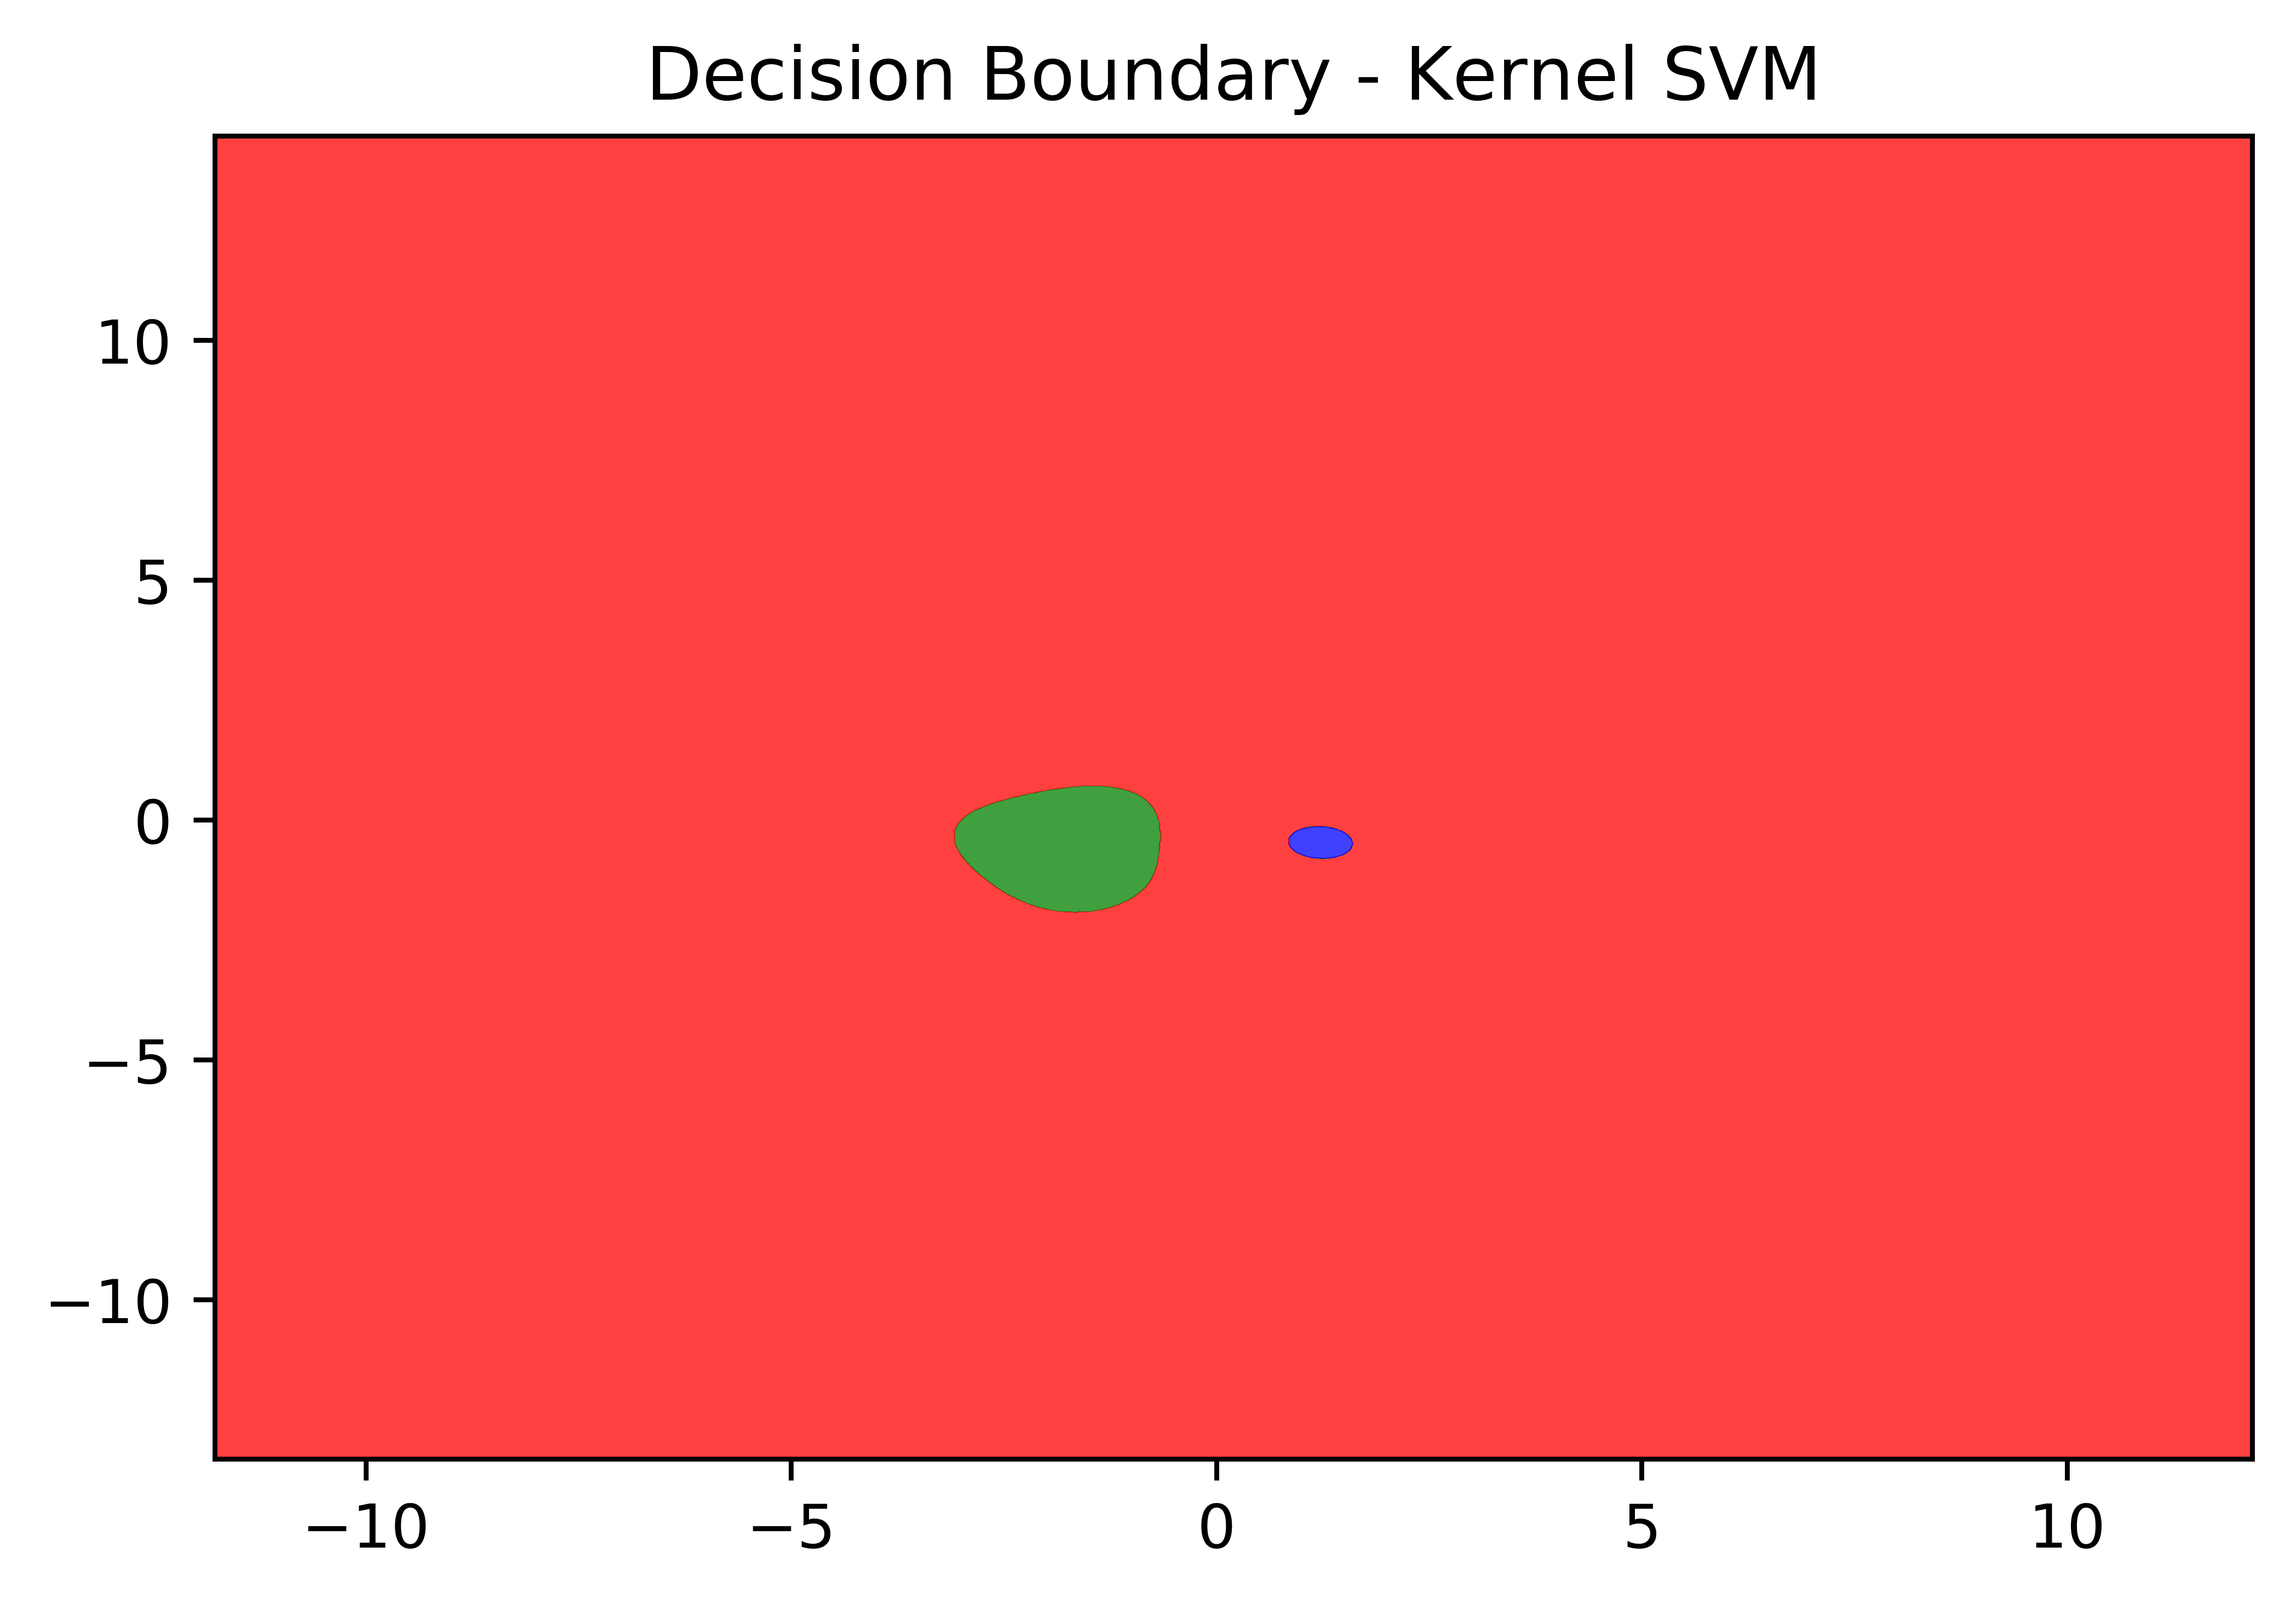

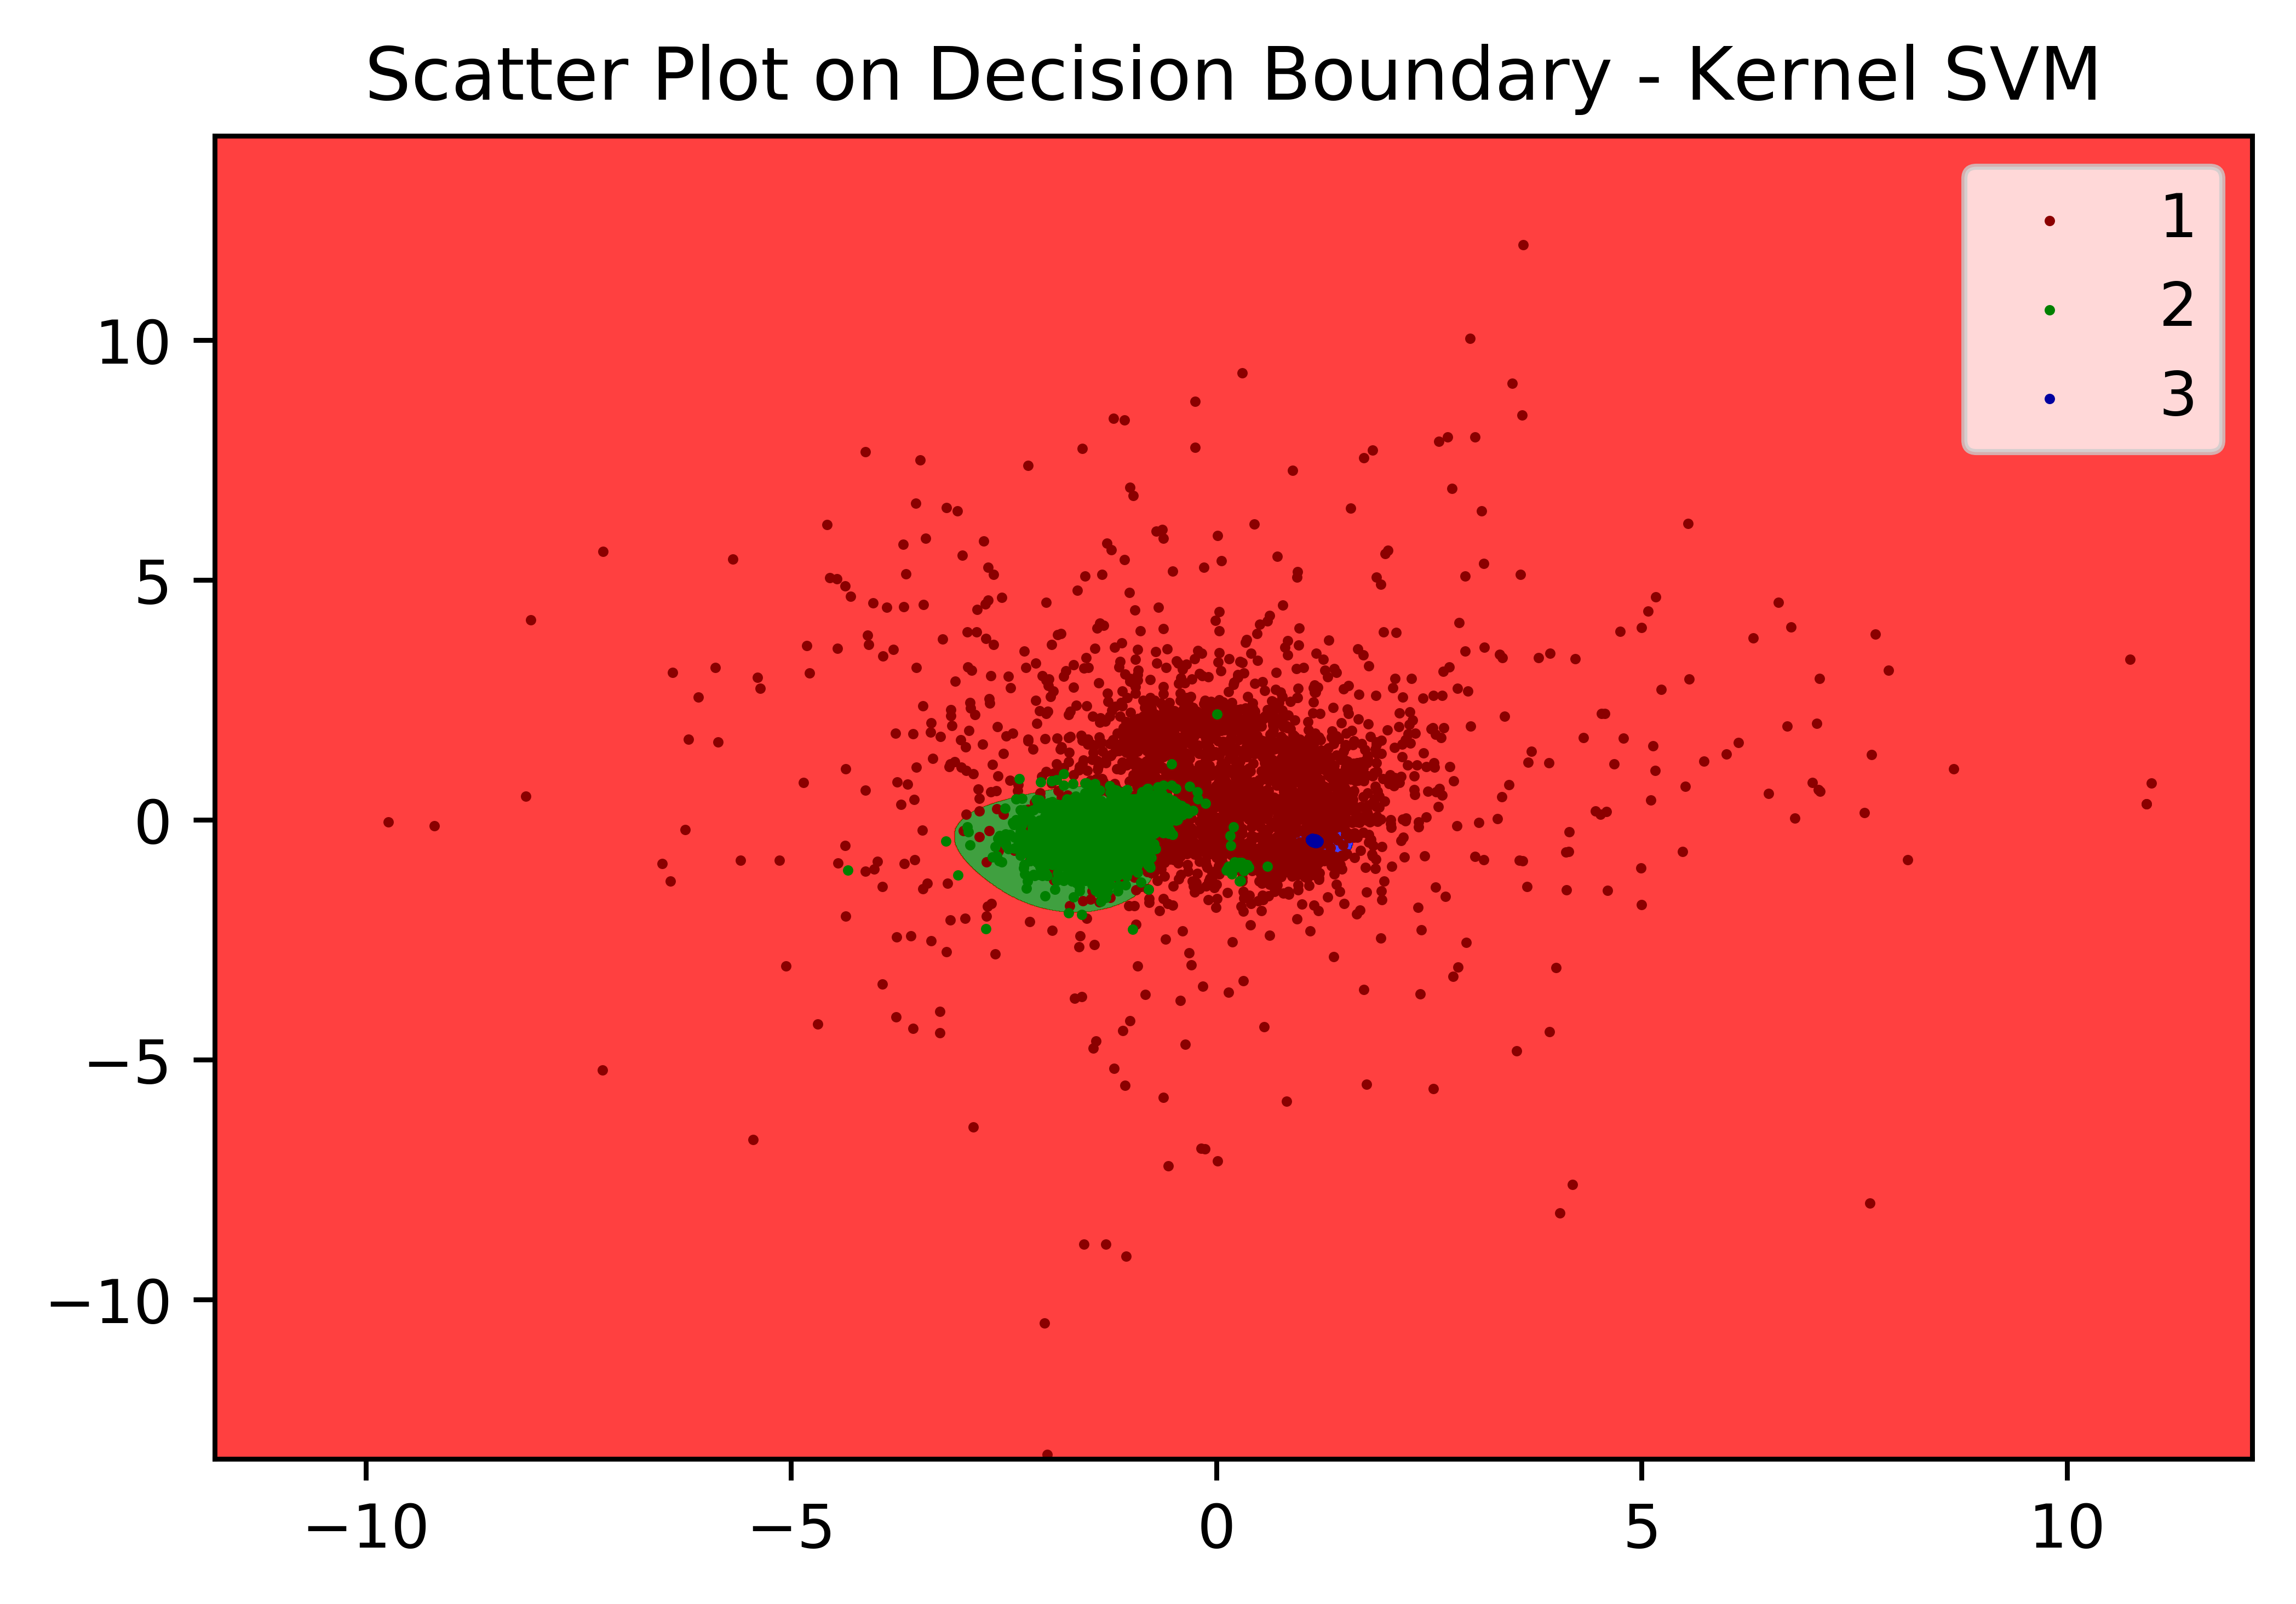

In [39]:
LDA_Plot(z_train, y_train, z_test, y_test, func = classifier_z.predict ,title = "Kernel SVM")